In [1]:
import pandas as pd
import json

def load_yelp_json(filepath):
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

df1 = load_yelp_json('split_file_1.json')
df2 = load_yelp_json('split_file_2.json')
df3 = load_yelp_json('split_file_3.json')

df = pd.concat([df1, df2, df3], ignore_index=True)
print(df.shape)
print(df.columns.tolist())
print(df[['stars', 'text']].head())

(2097084, 9)
['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date']
   stars                                               text
0    3.0  If you decide to eat here, just be aware it is...
1    5.0  I've taken a lot of spin classes over the year...
2    3.0  Family diner. Had the buffet. Eclectic assortm...
3    5.0  Wow!  Yummy, different,  delicious.   Our favo...
4    4.0  Cute interior and owner (?) gave us tour of up...


In [2]:
df_sample=df.groupby('stars',group_keys=False).apply(lambda x:x.sample(min(len(x),40000),random_state=42)).reset_index(drop=True)
print(df_sample['stars'].value_counts())

print(df_sample.shape)

C:\Users\2024\AppData\Local\Temp\ipykernel_22704\62916963.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample=df.groupby('stars',group_keys=False).apply(lambda x:x.sample(min(len(x),40000),random_state=42)).reset_index(drop=True)


stars
1.0    40000
2.0    40000
3.0    40000
4.0    40000
5.0    40000
Name: count, dtype: int64
(200000, 9)


In [3]:
from textblob import TextBlob
if 'sentiment_polarity' not in df_sample.columns:
    df_sample['sentiment_polarity']=df_sample['text'].apply(lambda x:TextBlob(x).sentiment.polarity)

In [4]:
# metadata features
df_sample['word_count'] = df_sample['text'].str.split().str.len()
df_sample['exclamation_count'] = df_sample['text'].str.count('!')
df_sample['capital_ratio'] = df_sample['text'].apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))

# text features
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2), min_df=5)
X_text = tfidf.fit_transform(df_sample['text'])

meta_cols = ['word_count', 'exclamation_count', 'capital_ratio', 'sentiment_polarity']
X_meta = df_sample[meta_cols].values

from scipy.sparse import hstack, csr_matrix
X = hstack([X_text, csr_matrix(X_meta)])
y = df_sample['stars']

print(X.shape)

(200000, 5004)


In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, X_test.shape)

(160000, 5004) (40000, 5004)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))

# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=20, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, rf_preds))

C:\Users\2024\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression ===
              precision    recall  f1-score   support

         1.0       0.62      0.73      0.67      8000
         2.0       0.47      0.42      0.44      8000
         3.0       0.48      0.43      0.45      8000
         4.0       0.50      0.50      0.50      8000
         5.0       0.64      0.67      0.66      8000

    accuracy                           0.55     40000
   macro avg       0.54      0.55      0.55     40000
weighted avg       0.54      0.55      0.55     40000

=== Random Forest ===
              precision    recall  f1-score   support

         1.0       0.58      0.80      0.67      8000
         2.0       0.49      0.34      0.40      8000
         3.0       0.48      0.37      0.42      8000
         4.0       0.48      0.38      0.42      8000
         5.0       0.56      0.75      0.64      8000

    accuracy                           0.53     40000
   macro avg       0.52      0.53      0.51     40000
weighted avg       0.52    

In [7]:
from xgboost import XGBClassifier

y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb = XGBClassifier(objective='multi:softmax', num_class=5, max_depth=6, n_estimators=200, random_state=42)
xgb.fit(X_train, y_train_xgb)
xgb_preds = xgb.predict(X_test) + 1
print("=== XGBoost ===")
print(classification_report(y_test, xgb_preds))

=== XGBoost ===
              precision    recall  f1-score   support

         1.0       0.67      0.73      0.70      8000
         2.0       0.49      0.48      0.49      8000
         3.0       0.49      0.43      0.46      8000
         4.0       0.50      0.50      0.50      8000
         5.0       0.66      0.70      0.68      8000

    accuracy                           0.57     40000
   macro avg       0.56      0.57      0.56     40000
weighted avg       0.56      0.57      0.56     40000



In [8]:
for name, preds in [('Logistic Regression', lr_preds), ('Random Forest', rf_preds), ('XGBoost', xgb_preds)]:
    print(name, f1_score(y_test, preds, average='weighted'))

Logistic Regression 0.5454766169904617
Random Forest 0.5102607635403777
XGBoost 0.5642106136791815


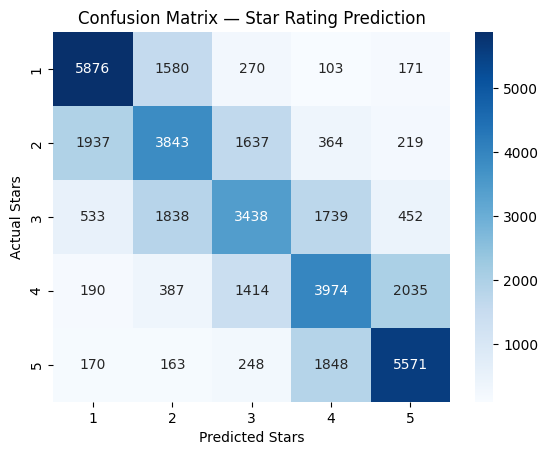

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

best_preds = xgb_preds  # swap to xgb_preds or lr_preds if that scored higher
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(1,6), yticklabels=range(1,6))
plt.xlabel('Predicted Stars'); plt.ylabel('Actual Stars')
plt.title('Confusion Matrix — Star Rating Prediction')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
importances = xgb.feature_importances_  # or xgb.feature_importances_
feature_names = list(tfidf.get_feature_names_out()) + meta_cols
top20 = sorted(zip(feature_names, importances), key=lambda x: -x[1])[:20]
for feat, score in top20:
    print(f"{feat}: {score:.4f}")

sentiment_polarity: 0.0052
stay away: 0.0026
told: 0.0026
highly: 0.0024
called: 0.0023
company: 0.0023
refused: 0.0022
refund: 0.0021
decent: 0.0020
professional: 0.0020
ok: 0.0020
exclamation_count: 0.0019
manager: 0.0018
worst: 0.0018
zero stars: 0.0018
okay: 0.0018
scam: 0.0018
zero: 0.0017
rude: 0.0016
average: 0.0015


In [16]:
df_sample['predicted_stars'] = xgb.predict(X)+1  # predict on full sample

business_summary = df_sample.groupby('business_id').agg(
    avg_actual=('stars', 'mean'),
    avg_predicted=('predicted_stars', 'mean'),
    review_count=('stars', 'count')
).reset_index()
business_summary['gap'] = business_summary['avg_actual'] - business_summary['avg_predicted']

flagged = business_summary[
    (business_summary['gap'] > 0.75) & (business_summary['review_count'] >= 10)
].sort_values('gap', ascending=False)

print(flagged.head(10))
print(f"\nTotal flagged businesses: {len(flagged)}")

                  business_id  avg_actual  avg_predicted  review_count  \
24799  kfqgGm2hJUj4NXEkkk1qIA    4.133333       3.066667            15   
7561   Di6uZDhcwnLsgM66Z4fNfw    3.700000       2.700000            10   
857    0hCrds3sgFAYzsZolg3jcg    3.666667       2.833333            12   
5417   9Q5GrEg9iy_RXuRkxIENVg    3.909091       3.090909            11   
5706   A1UcdK-Eb4xsqXequ4zNUA    4.100000       3.300000            10   
24811  khVgwowtBDRWHp77qDFmqQ    3.800000       3.000000            10   
28478  rpZrUHxtj5JZuq76FkbNdA    4.100000       3.300000            10   
20360  c2CvYlRRcA17h-UVyBFd8w    3.785714       3.000000            14   

            gap  
24799  1.066667  
7561   1.000000  
857    0.833333  
5417   0.818182  
5706   0.800000  
24811  0.800000  
28478  0.800000  
20360  0.785714  

Total flagged businesses: 8


In [17]:
sample_reviews = df_sample[df_sample['business_id'] == 'kfqgGm2hJUj4NXEkkk1qIA'][['stars', 'text']]
print(sample_reviews.to_string())

        stars                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [18]:
underrated = business_summary[
    (business_summary['gap'] < -0.75) & (business_summary['review_count'] >= 10)
].sort_values('gap')
print(underrated.head(10))

                  business_id  avg_actual  avg_predicted  review_count  \
29292  tS47dXDlx9t-6B_F56cKUA    2.000000       3.100000            10   
19129  _afbAT4NgVAscxIOFOwr0Q    2.076923       2.923077            13   
12113  MkYu8dMDQFX830cIqMo90Q    2.200000       3.000000            10   
14291  R4RwLCBjC19UqsN4JbpWng    1.315789       2.105263            19   

            gap  
29292 -1.100000  
19129 -0.846154  
12113 -0.800000  
14291 -0.789474  


In [19]:
sample_reviews = df_sample[df_sample['business_id'] == 'tS47dXDlx9t-6B_F56cKUA'][['stars', 'text']]
print(sample_reviews.to_string())

        stars                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [20]:
import joblib
joblib.dump(xgb, 'yelp_star_predictor_xgb.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']